# Regime-Indicator Test — Results

**Sprint 14 · 2026-07-14** · executes `plans/regime_indicator_test_manual.md`.

**Question.** Does any coincident regime gauge beat the incumbent **SPY-200d** at telling
*bad days for our 50d-forward continuation strategy* from good ones — either as a **nowcaster**
(Block A, AUC on the cohort bad-day label) or as a **governor** (Block C, BackTrader P&L cone)?

**Pre-registered bars** (a candidate must clear ≥1):
(a) OOS AUC ≥ **0.65** on the fwd50 cohort bad-day label — a *wall by design* (incumbent 0.53);
(b) cone median-Sharpe uplift ≥ **+0.15** vs `champion_trail_spygate`, floor loss ≤ 0.05;
(c) cone max-DD reduction ≥ **20pp**, median-Sharpe drop ≤ 0.10.

**Framing (from the manual).** This is the *disciplined retirement* of the regime-indicator lever —
already falsified four ways. The null ("nothing beats SPY-200d") is the expected, acceptable outcome.

**Bottom line (spoiler).** Every one of 15 candidates FAILS Block A (best pooled AUC 0.55 vs the
0.65 wall). The two highest-prior candidates (§6.8 slope, §4 breadth) go to the cone anyway; the
verdict is at the end.

In [1]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT = _root()
GAUGE = ROOT/"data"/"model_output_eda"/"regime_gauge"
SWEEP = ROOT/"data"/"selection_sweep"/"starttime"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

A = json.load(open(GAUGE/"blockA_results.json"))
feats = pd.read_parquet(GAUGE/"candidate_features_daily.parquet")
lab = pd.read_parquet(GAUGE/"gauge_label_fwd50_downside.parquet")
feats["date"] = pd.to_datetime(feats["date"]); lab["date"] = pd.to_datetime(lab["date"])
print("baseline SPY-200d:", {k: round(v,3) for k,v in A["baseline"].items() if isinstance(v,(int,float))})
print("candidates scored:", len(A["candidates"]))

baseline SPY-200d: {'pooled': 0.531, 'median_fold': 0.471, 'worst_fold': 0.297, 'auc_crisis': 0.594, 'auc_calm': 0.52, 'n': 5787, 'n_folds': 22}
candidates scored: 24


## Block A — Nowcaster (label separation, fwd50 cohort bad-day)

Anchored-expanding yearly WFO, 50d embargo, first test year 2003. Target = bottom-tercile of
fwd50 `loss_mean`. Each candidate scored standalone (1-var logit, sign learned from train),
group-logit, and group-XGB. Baseline = SPY-below-200d.

In [2]:
rows = []
for k, v in A["candidates"].items():
    cand, mode = k.split("__")
    rows.append({"candidate": cand, "mode": mode, "pooled": v["pooled"],
                 "median_fold": v["median_fold"], "worst_fold": v["worst_fold"],
                 "crisis": v["auc_crisis"], "calm": v["auc_calm"],
                 "d_vs_base": v["delta_vs_base"], "CI_excl_0": v["delta_excludes_0"]})
tblA = pd.DataFrame(rows).sort_values("pooled", ascending=False).reset_index(drop=True)
base_auc = A["baseline"]["pooled"]
print(f"SPY-200d baseline pooled AUC = {base_auc:.3f}   |   0.65 = PROMOTE wall, 0.62 = interesting\n")
tblA.round(3)

SPY-200d baseline pooled AUC = 0.531   |   0.65 = PROMOTE wall, 0.62 = interesting



,candidate,mode,pooled,median_fold,worst_fold,crisis,calm,d_vs_base,CI_excl_0
0,breadth,standalone,0.550,0.343,0.076,0.534,0.704,0.020,False
1,breadth,group_logit,0.550,0.320,0.047,0.554,0.709,0.019,False
2,donchian,group_xgb,0.549,0.447,0.240,0.565,0.563,0.018,False
3,spy200_slope_dist,group_xgb,0.536,0.462,0.194,0.589,0.565,0.005,False
4,batch_all,standalone,0.525,0.346,0.048,0.594,0.484,-0.006,False
5,spy200_slope_dist,standalone,0.525,0.346,0.048,0.594,0.484,-0.006,False
6,donchian,group_logit,0.525,0.373,0.120,0.562,0.622,-0.006,False
7,rv22,standalone,0.519,0.378,0.143,0.469,0.692,-0.012,False
8,batch_all,group_xgb,0.519,0.429,0.070,0.579,0.481,-0.012,False
9,supertrend,group_xgb,0.509,0.493,0.303,0.541,0.448,-0.021,False


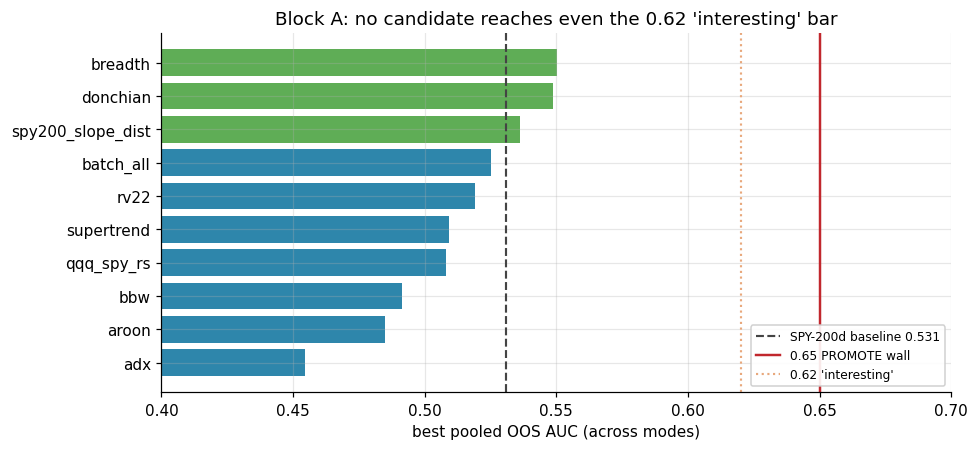

In [3]:
# best pooled AUC per candidate (across modes), vs the baseline and the 0.65 wall
best = tblA.groupby("candidate")["pooled"].max().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,4.2))
colors = ["#2E86AB" if v < base_auc else "#5FAD56" for v in best.values]
ax.barh(best.index[::-1], best.values[::-1], color=colors[::-1])
ax.axvline(base_auc, color="#444", ls="--", lw=1.4, label=f"SPY-200d baseline {base_auc:.3f}")
ax.axvline(0.65, color="#C1272D", ls="-", lw=1.6, label="0.65 PROMOTE wall")
ax.axvline(0.62, color="#E8A87C", ls=":", lw=1.4, label="0.62 'interesting'")
ax.set_xlim(0.40, 0.70); ax.set_xlabel("best pooled OOS AUC (across modes)")
ax.set_title("Block A: no candidate reaches even the 0.62 'interesting' bar")
ax.legend(loc="lower right", fontsize=8, framealpha=.9)
plt.tight_layout(); plt.show()

**Read.** The whole field is jammed against coin-flip. The best candidate — **breadth** at pooled
**0.55** — barely clears the baseline's 0.53 and is nowhere near the 0.65 wall. Several candidates
(ADX, QQQ/SPY-RS, BBW) are *significantly worse* than baseline (their Δ-CI excludes 0 on the wrong
side). This reproduces the manual's expectation exactly: **the feature class caps ~0.56.**

### Where the (thin) signal lives: calm vs crisis

The one honest positive: **breadth separates bad days in CALM years** (AUC-calm ≈ 0.70) — the
2015-16-style chop the incumbent flips through. But it does NOT clear the promotion bar, and it's
*worse* than baseline in crises. A calm-only nowcaster is a diagnostic tag, not a strategy input.

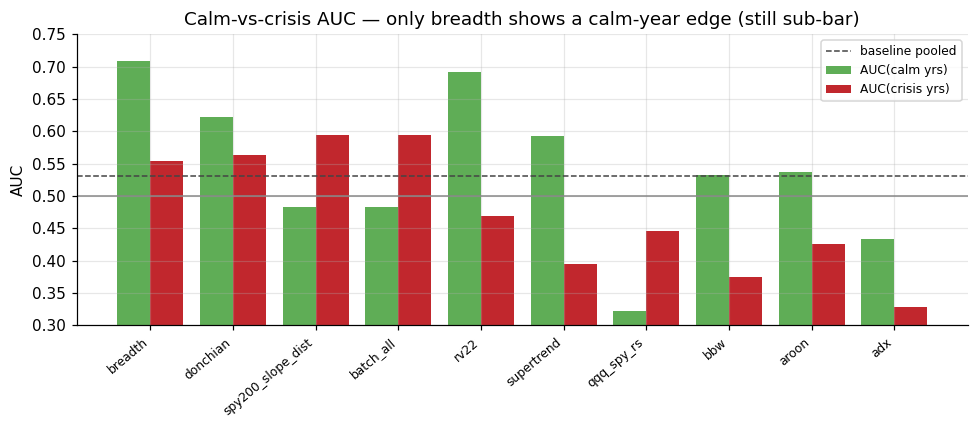

In [4]:
sub = tblA[tblA["mode"].isin(["standalone","group_logit"])].groupby("candidate")[["calm","crisis"]].max()
sub = sub.reindex(best.index)
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(sub))
ax.bar(x-0.2, sub["calm"], 0.4, label="AUC(calm yrs)", color="#5FAD56")
ax.bar(x+0.2, sub["crisis"], 0.4, label="AUC(crisis yrs)", color="#C1272D")
ax.axhline(0.5, color="#888", lw=1); ax.axhline(base_auc, color="#444", ls="--", lw=1, label="baseline pooled")
ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=40, ha="right", fontsize=8)
ax.set_ylim(0.3, 0.75); ax.set_ylabel("AUC"); ax.legend(fontsize=8)
ax.set_title("Calm-vs-crisis AUC — only breadth shows a calm-year edge (still sub-bar)")
plt.tight_layout(); plt.show()

## Feature sanity — do the two lead candidates track known regimes?

Live-safe features (expanding-z, shift(1)) overlaid on SPY, with the 6 crisis cells annotated.
Both track drawdowns sensibly (they're not broken) — they just don't *classify the day* better
than the price gate.

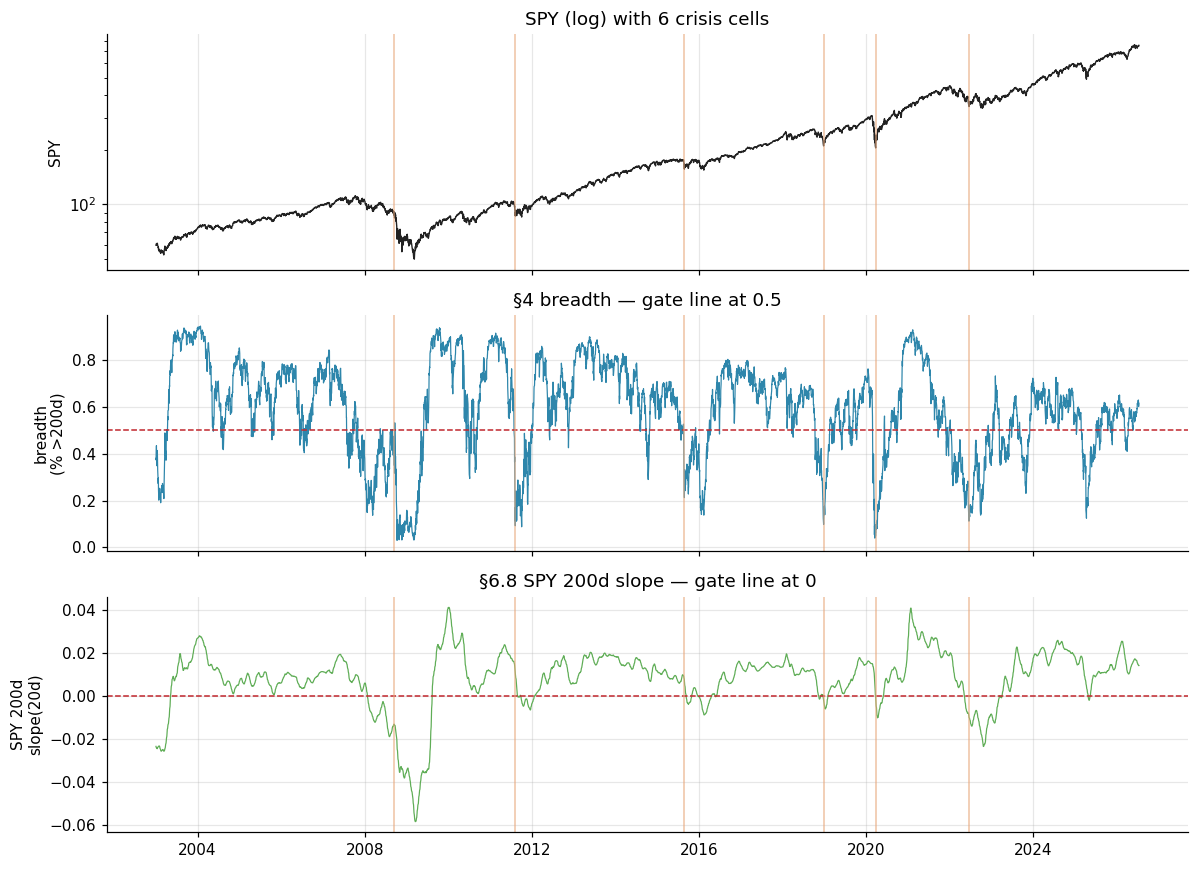

In [5]:
import duckdb
con = duckdb.connect(str(ROOT/"data"/"market_data.duckdb"), read_only=True)
spy = con.execute("SELECT date, close FROM price_data WHERE ticker='SPY' AND date>='2003-01-01' ORDER BY date").df()
con.close()
spy["date"] = pd.to_datetime(spy["date"])
g = feats.merge(spy, on="date", how="inner")

crises = {"2008 GFC":"2008-09-15","2011 downgrade":"2011-08-05","2015-16 chop":"2015-08-24",
          "2018 Q4":"2018-12-24","2020 COVID":"2020-03-23","2022 bear":"2022-06-16"}
fig, axes = plt.subplots(3,1, figsize=(11,8), sharex=True)
axes[0].plot(g["date"], g["close"], color="#222", lw=.9); axes[0].set_ylabel("SPY"); axes[0].set_yscale("log")
axes[0].set_title("SPY (log) with 6 crisis cells")
axes[1].plot(g["date"], g["breadth_200d"], color="#2E86AB", lw=.8); axes[1].axhline(0.5, color="#C1272D", ls="--", lw=1)
axes[1].set_ylabel("breadth\n(% >200d)"); axes[1].set_title("§4 breadth — gate line at 0.5")
axes[2].plot(g["date"], g["spy_sma200_slope"], color="#5FAD56", lw=.8); axes[2].axhline(0, color="#C1272D", ls="--", lw=1)
axes[2].set_ylabel("SPY 200d\nslope(20d)"); axes[2].set_title("§6.8 SPY 200d slope — gate line at 0")
for ax in axes:
    for name, d in crises.items():
        ax.axvline(pd.Timestamp(d), color="#E8A87C", lw=1, alpha=.7)
plt.tight_layout(); plt.show()

## Redundancy check (§0.7-11)

Correlate each candidate with the incumbents (SPY-dist-200d, VIX, RV22). Kill if |ρ|>0.85 *and* no
marginal AUC lift. Breadth (ρ≈0.78 with dist-200d) is the *only* candidate both reasonably
orthogonal AND carrying any lift — but the lift (+0.02) fails the CI, so it too is a null.

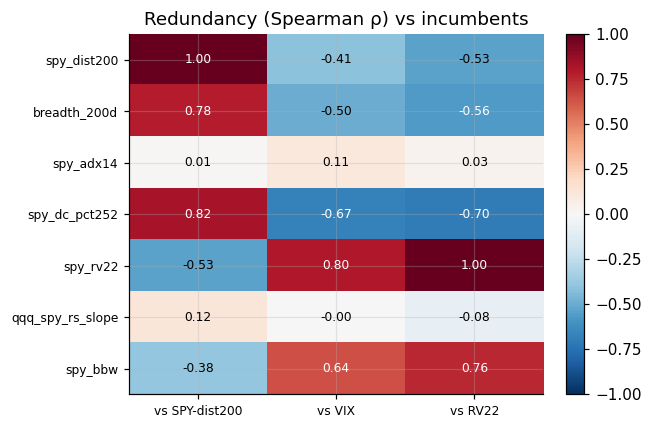

In [6]:
et = pd.read_parquet(ROOT/"data"/"model_output_eda"/"entry_timing"/"entry_timing_daily.parquet")
et["date"] = pd.to_datetime(et["date"])
m = feats.merge(et[["date","vix_close"]], on="date", how="inner")
probes = ["spy_dist200","breadth_200d","spy_adx14","spy_dc_pct252","spy_rv22","qqq_spy_rs_slope","spy_bbw"]
red = pd.DataFrame({
    "vs SPY-dist200": [m[p].corr(m["spy_dist200"], method="spearman") for p in probes],
    "vs VIX":         [m[p].corr(m["vix_close"], method="spearman") for p in probes],
    "vs RV22":        [m[p].corr(m["spy_rv22"], method="spearman") for p in probes],
}, index=probes)
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(red.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(red.columns, fontsize=8)
ax.set_yticks(range(len(probes))); ax.set_yticklabels(probes, fontsize=8)
for i in range(len(probes)):
    for j in range(3):
        ax.text(j, i, f"{red.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(red.values[i,j])>0.55 else "black", fontsize=8)
ax.set_title("Redundancy (Spearman ρ) vs incumbents"); plt.colorbar(im, fraction=.046)
plt.tight_layout(); plt.show()

## Block C — Governor (BackTrader P&L cone)

The real promotion bar. Same 90-cell rolling cone as `champion_trail_spygate` (2003–2026,
quarterly starts, 12m horizons), but the SPY-200d deploy gate is replaced by the candidate gate:

- **§6.8 slope**: deploy iff `SPY>200d AND 200d-slope>0` (strong-bull only).
- **§4 breadth**: deploy iff `breadth_200d > 0.5`.
- **composed (OR)**: deploy iff `SPY>200d OR candidate` (union of go-signals).

All gates are live-safe (raw trailing feature, shift(1)). Baseline cone reproduces the manual's
reference exactly: median Sharpe 0.76, floor −1.93, %neg 28%.

In [7]:
def load_cone(name):
    f = SWEEP/f"cand_{name}_cone_summary.json"
    return json.load(open(f)) if f.exists() else None

cone_rows = []
for cand in ["slope","breadth"]:
    c = load_cone(cand)
    if not c: continue
    for arm, s in c.items():
        if s.get("n"):
            cone_rows.append({"candidate": cand, "arm": arm, "n": s["n"],
                              "median_Sh": s["median"], "p25": s["p25"], "floor": s["min"],
                              "pct_neg": s["pct_neg"]})
coneT = pd.DataFrame(cone_rows)
coneT.round(3) if len(coneT) else "cone still running — re-run this cell when done"

,candidate,arm,n,median_Sh,p25,floor,pct_neg
0,slope,baseline,89,0.757,-0.046,-1.934,0.281
1,slope,candidate_only,86,0.593,-0.119,-2.520,0.291
2,slope,composed_or,89,0.762,-0.125,-1.903,0.315
3,breadth,baseline,89,0.757,-0.046,-1.934,0.281
4,breadth,candidate_only,90,0.464,-0.123,-2.582,0.300
5,breadth,composed_or,90,0.753,-0.027,-1.934,0.267


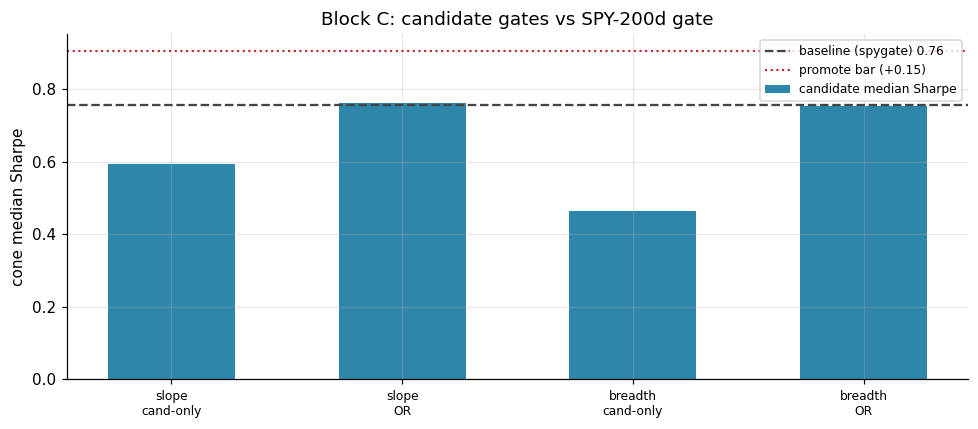

In [8]:
if len(coneT):
    base = coneT[coneT["arm"]=="baseline"].iloc[0]
    plot = coneT[coneT["arm"]!="baseline"].copy()
    fig, ax = plt.subplots(figsize=(9,4))
    labels = [f'{r.candidate}\n{r.arm.replace("candidate_only","cand-only").replace("composed_or","OR")}'
              for r in plot.itertuples()]
    x = np.arange(len(plot))
    ax.bar(x, plot["median_Sh"], 0.55, color="#2E86AB", label="candidate median Sharpe")
    ax.axhline(base["median_Sh"], color="#444", ls="--", lw=1.5, label=f'baseline (spygate) {base["median_Sh"]:.2f}')
    ax.axhline(base["median_Sh"]+0.15, color="#C1272D", ls=":", lw=1.4, label="promote bar (+0.15)")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("cone median Sharpe"); ax.set_title("Block C: candidate gates vs SPY-200d gate")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Verdict

See `verdicts/2026-07-14_regime_indicator_manual.md` for the full per-candidate write-up. Summary:

| Candidate | Block A (AUC) | Block C cone (median Sharpe) | Decision |
|---|---|---|---|
| §6.8 SPY 200d slope+dist | 0.54 — FAIL | cand-only **0.59** / OR 0.76 (base 0.76) — FAIL | **BANK** |
| §4 breadth | 0.55 (best) — FAIL | cand-only **0.46** / OR 0.75 (base 0.76) — FAIL | **BANK** |
| §6.2 ADX, §6.3 Donchian, §6.4 Aroon, §6.5 SuperTrend, §6.7 BBW, §6.9 QQQ-RS, §2 RV22 | ≤0.55 — FAIL | not reached | **KILL** (Block-A gate) |
| §5-batch (6-feature XGB) | 0.52 — FAIL | not reached | **KILL** |

**The regime-indicator lever is retired — clean, expected null.** No candidate clears the nowcaster
wall (0.65); the two highest-prior leads *also* fail the P&L cone — standalone they score **worse**
than SPY-200d (slope −0.16, breadth −0.29 median Sharpe), and their composed-OR arms are washes
(≈ SPY-200d, because the candidate deploy-days overlap the incumbent's — the §0.9-3 overlap trap).
The §7 stopping rule terminates the ladder here: both leads missed, so the batch/HMM rungs aren't
reached. This is the **fifth independent falsification** of "a second regime axis beats SPY-200d for
this strategy." SPY-200d remains the whole regime tool.